# MAP5935 - Statistical Learning (Chapter 8 - Tree-Based Models)

**Prof. Christian Jäkel**

https://www.statlearning.com/

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots

import statsmodels.api as sm
from statsmodels.gam.api import BSplines, GLMGam

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

## *Conceptual Exercises*

### (3) Consider the Gini index, classification error, and entropy in a simple classification setting with two classes. Create a single plot that displays each of these quantities as a function of $\hat p_{m1}$. The x-axis should display  $\hat p_{m1}$, ranging from 0 to 1, and the y-axis should display the value of the Gini index, classification error, and entropy.

**Solution**: In a binary classification problem, suppose a given node $ m $ contains observations belonging to two classes, with probabilities:
$$
\hat{p}_{m1} = p, \quad \hat{p}_{m2} = 1 - p.
$$
We can define three impurity measures that quantify how “mixed” the node is:

1. **Classification Error**:
   $$
   E(p) = 1 - \max(p, 1 - p)\quad\text{(8.5) - see pp. 338}
   $$

2. **Gini Index**:
   $$
   G(p) = 2p(1 - p)\quad\text{(8.6) - see pp. 338}
   $$

3. **Entropy (Deviance)**:
   $$
   H(p) = - \big[ p \log_2(p) + (1 - p) \log_2(1 - p) \big]\quad\text{(8.7) - see pp. 339}
   $$

In all indexes it is measured the uncertainty (in bits) in the class distribution. This implies that:  
   - Minimum impurity (0) occurs at $ p = 0 $ or $ p = 1 $.
   - Maximum impurity (1) occurs at $ p = 0.5 $.

These measures behave similarly — all are symmetric and concave, reaching their peak when the two classes are equally probable — but they differ in scale and curvature, which affects tree-splitting decisions.

#### Creating the plot for this problem

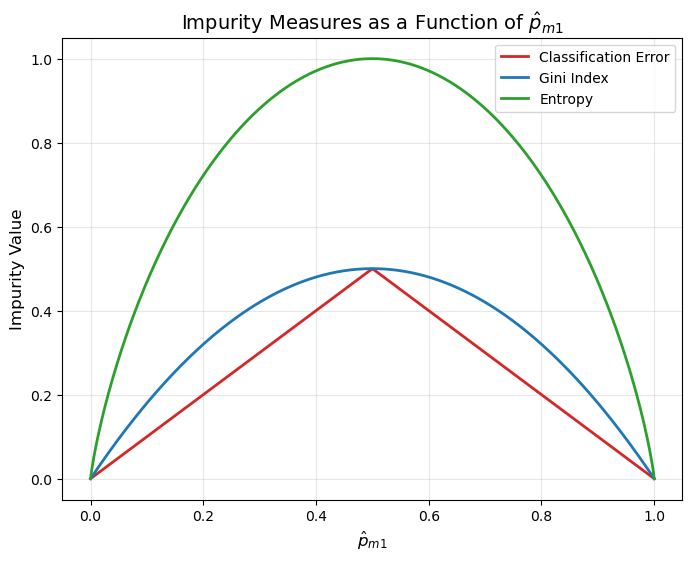

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Range of p values (probability of class 1)
p = np.linspace(0, 1, 500)
eps = 1e-12  # small value to avoid log(0)

# Classification error
classification_error = 1 - np.maximum(p, 1 - p)

# Gini index
gini = 2 * p * (1 - p)

# Entropy (using log base 2)
entropy = - (p * np.log2(p + eps) + (1 - p) * np.log2(1 - p + eps))

# --- Plot ---
plt.figure(figsize=(8, 6))
plt.plot(p, classification_error, label='Classification Error', color='tab:red', lw=2)
plt.plot(p, gini, label='Gini Index', color='tab:blue', lw=2)
plt.plot(p, entropy, label='Entropy', color='tab:green', lw=2)

plt.title('Impurity Measures as a Function of $\hat{p}_{m1}$', fontsize=14)
plt.xlabel(r'$\hat{p}_{m1}$', fontsize=12)
plt.ylabel('Impurity Value', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The figure above shows how **three impurity measures** — *Classification Error*, *Gini Index*, and *Entropy* — vary as a function of the class probability $\hat{p}_{m1}$ in a binary classification setting.

- All three curves are **symmetric around $\hat{p}_{m1} = 0.5$**.
- This symmetry reflects the fact that impurity depends only on *how mixed* the classes are, not on which class is labeled “1” or “2”.
- The impurity is **minimum (0)** when a node is pure, i.e., all samples belong to one class ($\hat{p}_{m1} = 0$ or $1$).
- The impurity is **maximum when $\hat{p}_{m1} = 0.5$**, meaning the node is perfectly mixed.

## *Applied Exercises*- Work in Progress

### (11) ...

### ...

In [1]:
from ISLP import load_data
Caravan = load_data('Caravan')
Caravan.columns

ModuleNotFoundError: No module named 'ISLP'